In [2]:
import httpx
import time
import pandas as pd
import re
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import json
from pathlib import Path
import numpy as np
from tqdm.auto import tqdm
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

/Users/mnatali/Projects/sentiment_analysis/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
model_name = "yangheng/deberta-v3-base-absa-v1.1"

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name).to(device)
model.eval()


def aspect_sentiment(text, aspect, batch_size=16, max_length=512, stride=64):
    encoded = tokenizer(
        text,
        aspect,
        truncation=True,
        max_length=max_length,
        stride=stride,
        return_overflowing_tokens=True,
        padding=True,
        return_tensors="pt"
    )

    input_keys = ["input_ids", "attention_mask", "token_type_ids"]
    input_keys = [k for k in input_keys if k in encoded]

    all_probs = []

    with torch.inference_mode():
        n_chunks = encoded["input_ids"].shape[0]

        for start in range(0, n_chunks, batch_size):
            end = start + batch_size

            batch = {
                k: encoded[k][start:end].to(device)
                for k in input_keys
            }

            outputs = model(**batch)
            probs = F.softmax(outputs.logits, dim=-1)
            all_probs.append(probs)

    avg_probs = torch.cat(all_probs, dim=0).mean(dim=0).cpu()

    return {
        model.config.id2label[i]: float(avg_probs[i])
        for i in range(len(avg_probs))
    }

Using device: mps


/Users/mnatali/Projects/sentiment_analysis/.venv/lib/python3.13/site-packages/transformers/convert_slow_tokenizer.py:564: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(
Skipping import of cpp extensions due to incompatible torch version 2.9.1 for torchao version 0.16.0             Please see https://github.com/pytorch/ao/issues/2919 for more info
W0629 21:13:40.998000 34859 torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


In [4]:
print(aspect_sentiment("I love the weather here! However, datacenters are a concern. The friendly neighbors hake up for it though!", "datacenters"))
sentiment = aspect_sentiment("I love the weather here! However, datacenters are a concern. The friendly neighbors hake up for it though!", "datacenters")

post_sentiments = []
post_sentiment_degrees = []

post_sentiments.append(max(sentiment, key=sentiment.get))
post_sentiment_degrees.append(max(sentiment.values()))

print(post_sentiments[0], post_sentiment_degrees[0])

{'Negative': 0.9916238188743591, 'Neutral': 0.007077292539179325, 'Positive': 0.0012989335227757692}
Negative 0.9916238188743591


In [5]:
file_path = Path("/Users/mnatali/Projects/sentiment_analysis/brightdata_across_social_media_analysis/brightdata_social_exports/quora_datacenters_posts.json")

with file_path.open("r", encoding="utf-8") as f:
    quora_posts = json.load(f)

In [6]:
posts = pd.DataFrame(columns=["ids", "text", "date", "upvotes", "number of answers", "shares", "views", "sentiment", "degree", "AWS", "Amazon", "Google", "Microsoft", "Azure", "Meta", "Oracle", "Equinix", "Digital Realty", "IBM", "Facebook", "Apple", "QTS", "Vantage", "CyrusOne", "CoreSite"])

post_ids = []
post_texts = []
post_dates = []
post_upvotes = []
post_num_answers = []
post_shares = []
post_views = []
post_sentiments = []
post_sentiment_degrees = []

a = 0

for q_post in quora_posts:
    a += 1

    post_ids.append(q_post["post_id"])
    post_texts.append(q_post["post_text"])
    post_dates.append(q_post["post_date"])
    post_upvotes.append(q_post["upvotes"])
    post_num_answers.append(q_post["over_all_answers"])
    post_shares.append(q_post["shares"])
    post_views.append(q_post["views"])

    '''
    sentiment = aspect_sentiment(q_post["post_text"], "datacenters")
    post_sentiments.append(max(sentiment, key=sentiment.get))
    post_sentiment_degrees.append(max(sentiment.values()))
    '''

    print("Posts scanned:", a, end="\r")

file_path = Path("/Users/mnatali/Projects/sentiment_analysis/brightdata_across_social_media_analysis/across_social_media_overall_sentiment_analysis/using_ABSA_CURRENT_TECHNIQUE/quora_sentiments_backup.json")

with file_path.open("r", encoding="utf-8") as f:
    sentiments = json.load(f)

post_sentiments = sentiments["sentiments"]
post_sentiment_degrees = sentiments["sentiment_degrees"]

posts["ids"] = post_ids
posts["text"] = post_texts
posts["date"] = post_dates
posts["upvotes"] = post_upvotes
posts["number of answers"] = post_num_answers
posts["shares"] = post_shares
posts["views"] = post_views
posts["sentiment"] = post_sentiments
posts["degree"] = post_sentiment_degrees

In [7]:
'''
sentiments_backup = post_sentiments.copy()
sentiment_degrees_backup = post_sentiment_degrees.copy()

data = {
    "sentiments": post_sentiments,
    "sentiment_degrees": post_sentiment_degrees
}

with open("quora_sentiments_backup.json", "w") as f:
    json.dump(data, f)
'''

'\nsentiments_backup = post_sentiments.copy()\nsentiment_degrees_backup = post_sentiment_degrees.copy()\n\ndata = {\n    "sentiments": post_sentiments,\n    "sentiment_degrees": post_sentiment_degrees\n}\n\nwith open("quora_sentiments_backup.json", "w") as f:\n    json.dump(data, f)\n'

In [8]:
posts = posts.astype({
    "ids": "string",
    "text": "string",
    "date": "string",
    "upvotes": "int64",
    "number of answers": "int64",
    "shares": "int64",
    "views": "int64",
    "sentiment": "string",
    "degree": "float64",
    "AWS": "bool",
    "Amazon": "bool",
    "Google": "bool",
    "Microsoft": "bool",
    "Azure": "bool",
    "Meta": "bool",
    "Oracle": "bool",
    "Equinix": "bool",
    "Digital Realty": "bool",
    "IBM": "bool",
    "Facebook": "bool",
    "Apple": "bool",
    "QTS": "bool",
    "Vantage": "bool",
    "CyrusOne": "bool",
    "CoreSite": "bool"
})

In [9]:
company_terms = ["AWS","Amazon","Google","Microsoft","Azure","Meta","Oracle","Equinix","Digital Realty","IBM","Facebook","Apple","QTS","Vantage","CyrusOne","CoreSite"]

for c in company_terms:
    posts[c] = posts["text"].str.contains(rf'\b{re.escape(c)}\b', case=False, na=False)

posts_with_company = posts[posts[company_terms].any(axis=1)]
posts_with_company.head()

,ids,text,date,upvotes,number of answers,shares,views,sentiment,degree,AWS,...,Oracle,Equinix,Digital Realty,IBM,Facebook,Apple,QTS,Vantage,CyrusOne,CoreSite
11,QW5zd2VyQDA6MzkyOTYxNzg=,"It Can Be Done, but it ain’t easy! Facebook In...",2017-03-16T13:23:23.398Z,4,7,0,803,Positive,0.437849,False,...,False,False,False,False,True,False,False,False,False,False
12,QW5zd2VyQDA6MzgzODkzNTk1,"32-bit processors like 80386, 486 and Pentium ...",2022-09-11T21:43:58.061Z,0,3,0,116,Neutral,0.722908,False,...,False,False,False,False,False,False,False,False,False,False
17,QW5zd2VyQDA6Nzc4OTI3NA==,You're on internet. Your privacy is already co...,2014-10-31T06:28:31.712Z,6,3,0,7309,Negative,0.768460,False,...,False,False,False,False,True,False,False,False,False,False
21,QW5zd2VyQDA6MTQ3Nzc0Mzc0NjI1NjQyNQ==,Lots of potential to pass bullshit as expertis...,2024-03-13T14:47:17.023Z,0,417,6,89,Positive,0.475844,False,...,True,False,False,False,False,False,False,False,False,False
23,QW5zd2VyQDA6MTQ4Mzc0Mzcy,I’m not so sure I buy your premise. Streaming ...,2019-06-18T19:42:33.034Z,2,3,0,939,Negative,0.565717,False,...,False,False,False,False,False,False,False,False,False,False


In [10]:
def remove_links(text):
    url_pattern = re.compile(r'\[https?://\S+\]|\(https?://\S+\)|\[www\.\S+\]|\(www\.\S+\)')
    cleaned_text = url_pattern.sub('', text)
    return cleaned_text

posts["text"] = posts["text"].apply(remove_links)

In [11]:
len(posts)
posts.head()

,ids,text,date,upvotes,number of answers,shares,views,sentiment,degree,AWS,...,Oracle,Equinix,Digital Realty,IBM,Facebook,Apple,QTS,Vantage,CyrusOne,CoreSite
0,QW5zd2VyQDA6NzM1OTcyNzk=,This is a great question which is going to req...,2018-02-18T22:07:30.861Z,4,65,0,1543,Positive,0.619682,False,...,False,False,False,False,False,False,False,False,False,False
1,QW5zd2VyQDA6MTQ3Nzc0Mzc1MTQ3OTk4Mg==,There are many sites that offer cloud mining s...,2024-04-04T01:33:35.222Z,0,4,0,381,Negative,0.593209,False,...,False,False,False,False,False,False,False,False,False,False
2,QW5zd2VyQDA6MzQ2MzQ4MDUy,There are many things you need to consider bef...,2022-03-26T03:04:03.138Z,0,4,0,366,Neutral,0.937892,False,...,False,False,False,False,False,False,False,False,False,False
3,QW5zd2VyQDA6NDMyMTExMzc=,"It all depends on your credential, Japanese la...",2017-05-01T00:55:30.403Z,21,13,0,22049,Positive,0.762447,False,...,False,False,False,False,False,False,False,False,False,False
4,QW5zd2VyQDA6MTQ3Nzc0MzY1MDg4OTQxOA==,Every website has its own physical infrastruct...,2023-03-17T12:53:02.910Z,0,1,0,209,Negative,0.640578,False,...,False,False,False,False,False,False,False,False,False,False


In [12]:
print(posts.columns)

Index(['ids', 'text', 'date', 'upvotes', 'number of answers', 'shares',
       'views', 'sentiment', 'degree', 'AWS', 'Amazon', 'Google', 'Microsoft',
       'Azure', 'Meta', 'Oracle', 'Equinix', 'Digital Realty', 'IBM',
       'Facebook', 'Apple', 'QTS', 'Vantage', 'CyrusOne', 'CoreSite'],
      dtype='object')


In [13]:
## total average sentiment calculation

pos = posts.loc[posts["sentiment"] == "Positive", "degree"].sum()
neg = posts.loc[posts["sentiment"] == "Negative", "degree"].sum()
total = posts["degree"].sum()
print("Average sentiment for all of quora: ", (pos-neg)/total)

Average sentiment for all of quora:  0.2213983651926531


In [14]:
pos = posts.loc[posts["sentiment"] == "Positive"]
neg = posts.loc[posts["sentiment"] == "Negative"]
neutral = posts.loc[posts["sentiment"] == "Neutral"]

print("Percent of posts that are neutral:", len(neutral)/len(posts))
print("Percent of posts that are negative:", len(neg)/len(posts))
print("Percent of posts that are positive:", len(pos)/len(posts))

really_pos = pos.loc[posts["degree"] > 0.90]
really_neg = neg.loc[posts["degree"] > 0.90]

if len(neg) != 0:
    print("Percent of negative posts that are really negative:", len(really_neg)/len(neg))
if len(pos) != 0:
    print("Percent of positive posts that are really positive:", len(really_pos)/len(pos))

Percent of posts that are neutral: 0.30923076923076925
Percent of posts that are negative: 0.24615384615384617
Percent of posts that are positive: 0.44461538461538463
Percent of negative posts that are really negative: 0.1
Percent of positive posts that are really positive: 0.15051903114186851


In [15]:
def avg_sentiment_calculation(dataset):
    pos = dataset.loc[dataset["sentiment"] == "Positive", "degree"].sum()
    neg = dataset.loc[dataset["sentiment"] == "Negative", "degree"].sum()
    total = dataset["degree"].sum()
    if total != 0:
        return (pos-neg)/total
    else:
        return 0

posts['year'] = pd.to_datetime(posts['date']).dt.year

year_datasets = {year: posts[posts['year'] == year] for year in range(2010, 2027)}

for i in range(2010, 2027):
    print(f"Number of posts from {i}: ", len(year_datasets[i]))
    if(len(year_datasets[i]) != 0):
        print(f"Average sentiment for quora posts from {i}: ", avg_sentiment_calculation(year_datasets[i]))

Number of posts from 2010:  4
Average sentiment for quora posts from 2010:  -0.2087800810534921
Number of posts from 2011:  20
Average sentiment for quora posts from 2011:  -0.03372786658416647
Number of posts from 2012:  12
Average sentiment for quora posts from 2012:  0.5619147521685989
Number of posts from 2013:  17
Average sentiment for quora posts from 2013:  0.0013113033231218689
Number of posts from 2014:  27
Average sentiment for quora posts from 2014:  0.17851528110145254
Number of posts from 2015:  41
Average sentiment for quora posts from 2015:  0.04826916642564992
Number of posts from 2016:  77
Average sentiment for quora posts from 2016:  0.11834724566657001
Number of posts from 2017:  129
Average sentiment for quora posts from 2017:  0.22823967391378966
Number of posts from 2018:  147
Average sentiment for quora posts from 2018:  -0.02184811309049218
Number of posts from 2019:  152
Average sentiment for quora posts from 2019:  0.10692856687553323
Number of posts from 2020

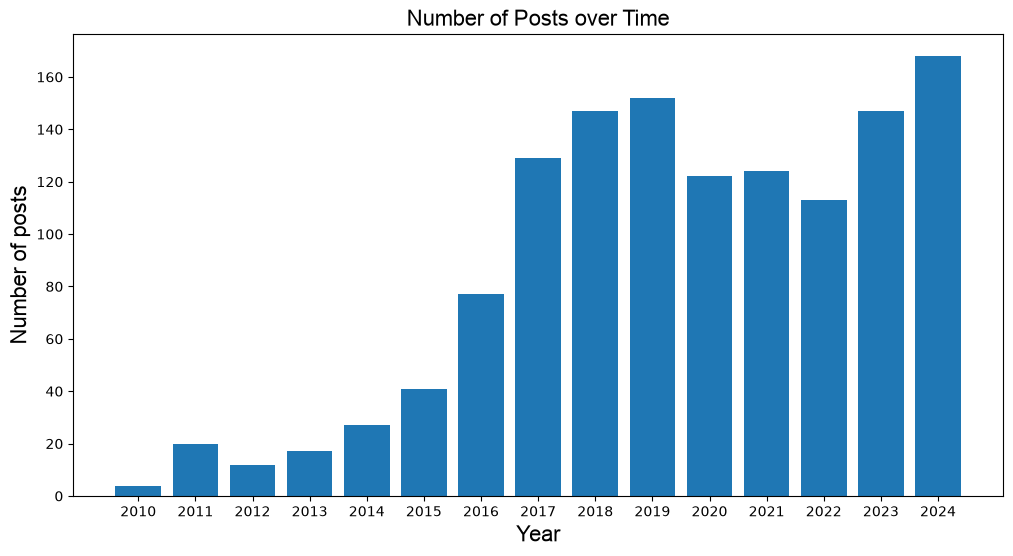

In [20]:
categories = ["2010", "2011", "2012", "2013", "2014", "2015", "2016", "2017", "2018", "2019", "2020", "2021", "2022", "2023", "2024"]
counts = [len(year_datasets[2010]), len(year_datasets[2011]), len(year_datasets[2012]), len(year_datasets[2013]), len(year_datasets[2014]), len(year_datasets[2015]), len(year_datasets[2016]), len(year_datasets[2017]), len(year_datasets[2018]), len(year_datasets[2019]), len(year_datasets[2020]), len(year_datasets[2021]), len(year_datasets[2022]), len(year_datasets[2023]), len(year_datasets[2024])]

plt.figure(figsize=(12, 6))
plt.bar(categories, counts)

plt.title(
    "Number of Posts over Time",
    fontsize=16,
    fontname="Arial"
)

plt.xlabel(
    "Year",
    fontsize=16,
    fontname="Arial"
)

plt.ylabel(
    "Number of posts",
    fontsize=16,
    fontname="Arial"
)
plt.show()

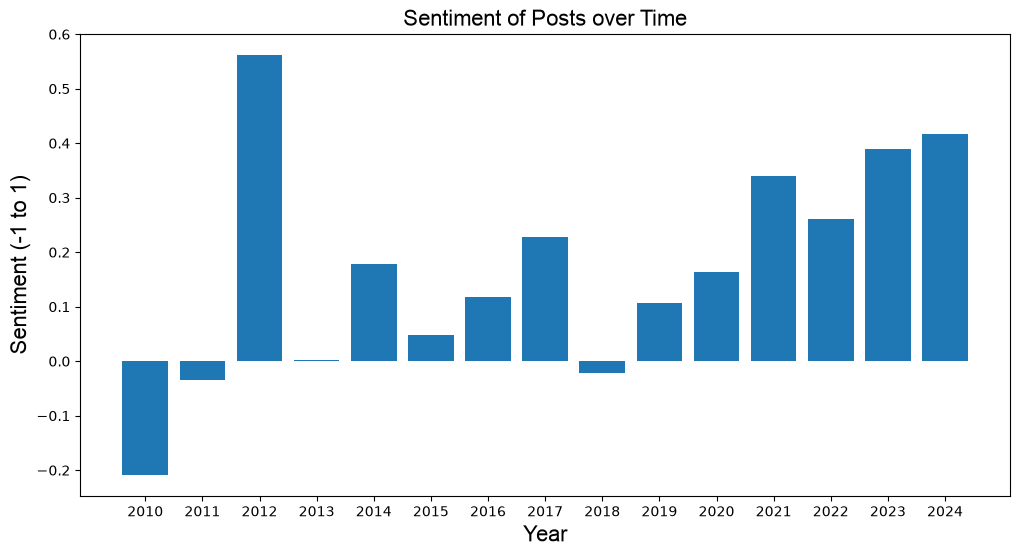

In [23]:
categories = ["2010", "2011", "2012", "2013", "2014", "2015", "2016", "2017", "2018", "2019", "2020", "2021", "2022", "2023", "2024"]
counts = [avg_sentiment_calculation(year_datasets[2010]), avg_sentiment_calculation(year_datasets[2011]), avg_sentiment_calculation(year_datasets[2012]), avg_sentiment_calculation(year_datasets[2013]), avg_sentiment_calculation(year_datasets[2014]), avg_sentiment_calculation(year_datasets[2015]), avg_sentiment_calculation(year_datasets[2016]), avg_sentiment_calculation(year_datasets[2017]), avg_sentiment_calculation(year_datasets[2018]), avg_sentiment_calculation(year_datasets[2019]), avg_sentiment_calculation(year_datasets[2020]), avg_sentiment_calculation(year_datasets[2021]), avg_sentiment_calculation(year_datasets[2022]), avg_sentiment_calculation(year_datasets[2023]), avg_sentiment_calculation(year_datasets[2024])]

plt.figure(figsize=(12, 6))
plt.bar(categories, counts)

plt.title(
    "Sentiment of Posts over Time",
    fontsize=16,
    fontname="Arial"
)

plt.xlabel(
    "Year",
    fontsize=16,
    fontname="Arial"
)

plt.ylabel(
    "Sentiment (-1 to 1)",
    fontsize=16,
    fontname="Arial"
)
plt.show()

In [18]:
def sentiment_by_company(company1, company2=None):
    company_posts = posts[
        (posts[company1] == True) | (posts[company2] == True) if company2 else (posts[company1] == True)
    ]
    return avg_sentiment_calculation(company_posts)

print("Number of Amazon-related posts:", len(posts[posts["AWS"] == True]) + len(posts[posts["Amazon"] == True]))
print("Average sentiment of AWS-related posts:", sentiment_by_company("AWS", "Amazon"))
print("Number of Google-related posts:", len(posts[posts["Google"] == True]))
print("Average sentiment of Google-related posts:", sentiment_by_company("Google"))
print("Number of Microsoft-related posts:", len(posts[posts["Microsoft"] == True]) + len(posts[posts["Azure"] == True]))
print("Average sentiment of Microsoft-related posts:", sentiment_by_company("Microsoft", "Azure"))
print("Number of Meta-related posts:", len(posts[posts["Meta"] == True]) + len(posts[posts["Facebook"] == True]))
print("Average sentiment of Meta-related posts:", sentiment_by_company("Meta"))
print("Number of Oracle-related posts:", len(posts[posts["Oracle"] == True]))
print("Average sentiment of Oracle-related posts:", sentiment_by_company("Oracle"))
print("Number of Equinix-related posts:", len(posts[posts["Equinix"] == True]))
print("Average sentiment of Equinix-related posts:", sentiment_by_company("Equinix"))
print("Number of Digital Realty-related posts:", len(posts[posts["Digital Realty"] == True]))
print("Average sentiment of Digital Realty-related posts:", sentiment_by_company("Digital Realty"))
print("Number of IBM-related posts:", len(posts[posts["IBM"] == True]))
print("Average sentiment of IBM-related posts:", sentiment_by_company("IBM"))
print("Number of Apple-related posts:", len(posts[posts["Apple"] == True]))
print("Average sentiment of Apple-related posts:", sentiment_by_company("Apple"))
print("Number of QTS-related posts:", len(posts[posts["QTS"] == True]))
print("Average sentiment of QTS-related posts:", sentiment_by_company("QTS"))
print("Number of Vantage-related posts:", len(posts[posts["Vantage"] == True]))
print("Average sentiment of Vantage-related posts:", sentiment_by_company("Vantage"))
print("Number of CyrusOne-related posts:", len(posts[posts["CyrusOne"] == True]))
print("Average sentiment of CyrusOne-related posts:", sentiment_by_company("CyrusOne"))
print("Number of CoreSite-related posts:", len(posts[posts["CoreSite"] == True]))
print("Average sentiment of CoreSite-related posts:", sentiment_by_company("CoreSite"))

Number of Amazon-related posts: 202
Average sentiment of AWS-related posts: 0.36026801927719726
Number of Google-related posts: 304
Average sentiment of Google-related posts: 0.2850776280480973
Number of Microsoft-related posts: 188
Average sentiment of Microsoft-related posts: 0.38700280366863676
Number of Meta-related posts: 120
Average sentiment of Meta-related posts: 0.5922290182774755
Number of Oracle-related posts: 15
Average sentiment of Oracle-related posts: 0.6777897258952073
Number of Equinix-related posts: 1
Average sentiment of Equinix-related posts: 1.0
Number of Digital Realty-related posts: 2
Average sentiment of Digital Realty-related posts: 0.0
Number of IBM-related posts: 48
Average sentiment of IBM-related posts: 0.22285790612793355
Number of Apple-related posts: 153
Average sentiment of Apple-related posts: 0.1605177733789753
Number of QTS-related posts: 0
Average sentiment of QTS-related posts: 0
Number of Vantage-related posts: 0
Average sentiment of Vantage-relat

In [19]:
def analysis_of_viral_posts(min):
    viral_posts = posts.loc[posts["upvotes"] >= min]
    non_viral_posts = posts.loc[posts["upvotes"] < min]
    print("What's considered viral: posts with over", min, "upvotes")
    print("Number of viral posts:", len(viral_posts))
    print("Average sentiment of viral posts:", avg_sentiment_calculation(viral_posts))
    print("Average sentiment of non-viral posts:", avg_sentiment_calculation(non_viral_posts))
    print("Amount percent of viral posts that are polar (degree) > 0.90: ", len(viral_posts.loc[viral_posts["degree"] > 0.90])/len(viral_posts))
    print("Percent of viral posts that are negative: ", (len(viral_posts.loc[viral_posts["sentiment"] == "Negative"]))/len(viral_posts))
    print("Percent of non-viral posts that are negative: ", (len(non_viral_posts.loc[non_viral_posts["sentiment"] == "Negative"]))/(len(non_viral_posts)))

analysis_of_viral_posts(200)
print("\n")
analysis_of_viral_posts(500)
print("\n")
analysis_of_viral_posts(1000)

What's considered viral: posts with over 200 upvotes
Number of viral posts: 52
Average sentiment of viral posts: 0.06170970427967739
Average sentiment of non-viral posts: 0.22743333436152585
Amount percent of viral posts that are polar (degree) > 0.90:  0.057692307692307696
Percent of viral posts that are negative:  0.36538461538461536
Percent of non-viral posts that are negative:  0.24118589743589744


What's considered viral: posts with over 500 upvotes
Number of viral posts: 33
Average sentiment of viral posts: -0.1219589551712951
Average sentiment of non-viral posts: 0.22950380957976502
Amount percent of viral posts that are polar (degree) > 0.90:  0.09090909090909091
Percent of viral posts that are negative:  0.45454545454545453
Percent of non-viral posts that are negative:  0.24072612470402527


What's considered viral: posts with over 1000 upvotes
Number of viral posts: 24
Average sentiment of viral posts: -0.16323022990344496
Average sentiment of non-viral posts: 0.228071915976